In [13]:
import matplotlib.pyplot
from numpy.ma.core import multiply


# Add line profiler
%load_ext line_profiler

#Import packages we need
from matplotlib import animation, rc
from matplotlib import pyplot as plt

#Lets have matplotlib "inline"
matplotlib.pyplot.ion()

#Set large figure sizes
#Note, this prevents nice figures for articles...
rc('figure', figsize=(16.0, 12.0))
rc('animation', html='html5')

import importlib

try:
    from StringIO import StringIO
except ImportError:
    from io import StringIO

from GPUSimulators import IPythonMagic
from GPUSimulators.common import Timer
from GPUSimulators.helpers import InitialConditions

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


In [14]:
%setup_logging --out=test_schemes.log TestSchemes

Global logger already initialized!


In [15]:
%cuda_context_handler my_context --no_autotuning

Registering my_context in user workspace


In [16]:
nx = 256
ny = 128
g = 9.81

h0, hu0, hv0, dx, dy = InitialConditions.bump(nx, ny, 100, 100, 15)

# print(my_context.autotuner.get)

arguments = {
    'context': my_context,
    'h0': h0, 'hu0': hu0, 'hv0': hv0,
    'nx': nx, 'ny': ny,
    'dx': dx, 'dy': dy, 
    'g': g,
    'compile_opts': []
}

t_end = 20

In [17]:
def plot(sim):
    h = sim.u0[0].download(sim.stream)
    
    plt.figure()
    plt.title(str(sim) + ", t=" + str(sim.sim_time()) + ", nt=" + str(sim.sim_steps()))
    extent = [0, sim.dx*sim.nx, 0, sim.dy*sim.ny]
    plt.imshow(h, vmin=0.49, vmax=0.52, extent=extent)
    plt.colorbar()

Simulation:   0%|          | 0/130 [00:00<?, ?it/s]

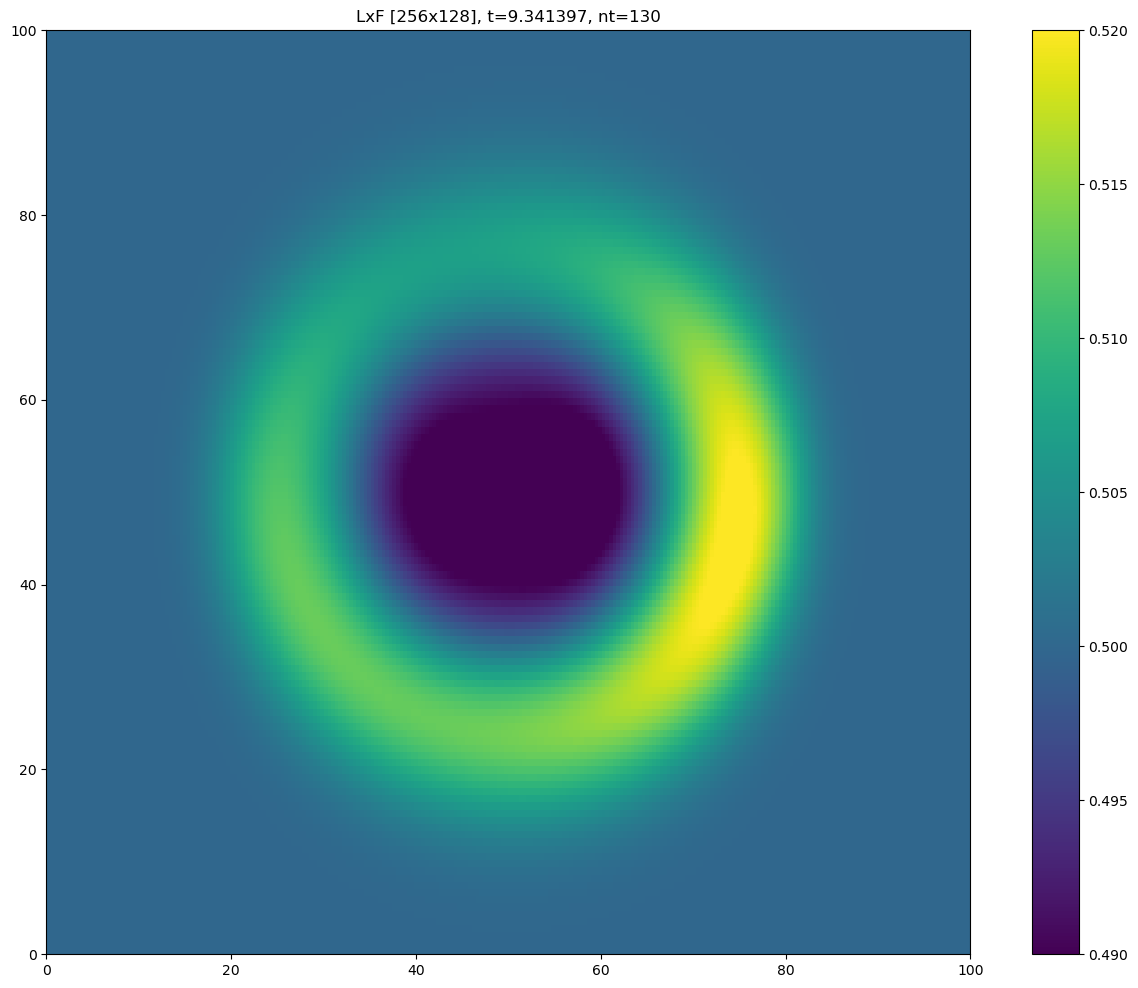

In [18]:
from GPUSimulators.model.lxf import LxF

with Timer("construct") as t:
    sim = LxF(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Simulation:   0%|          | 0/130 [00:00<?, ?it/s]

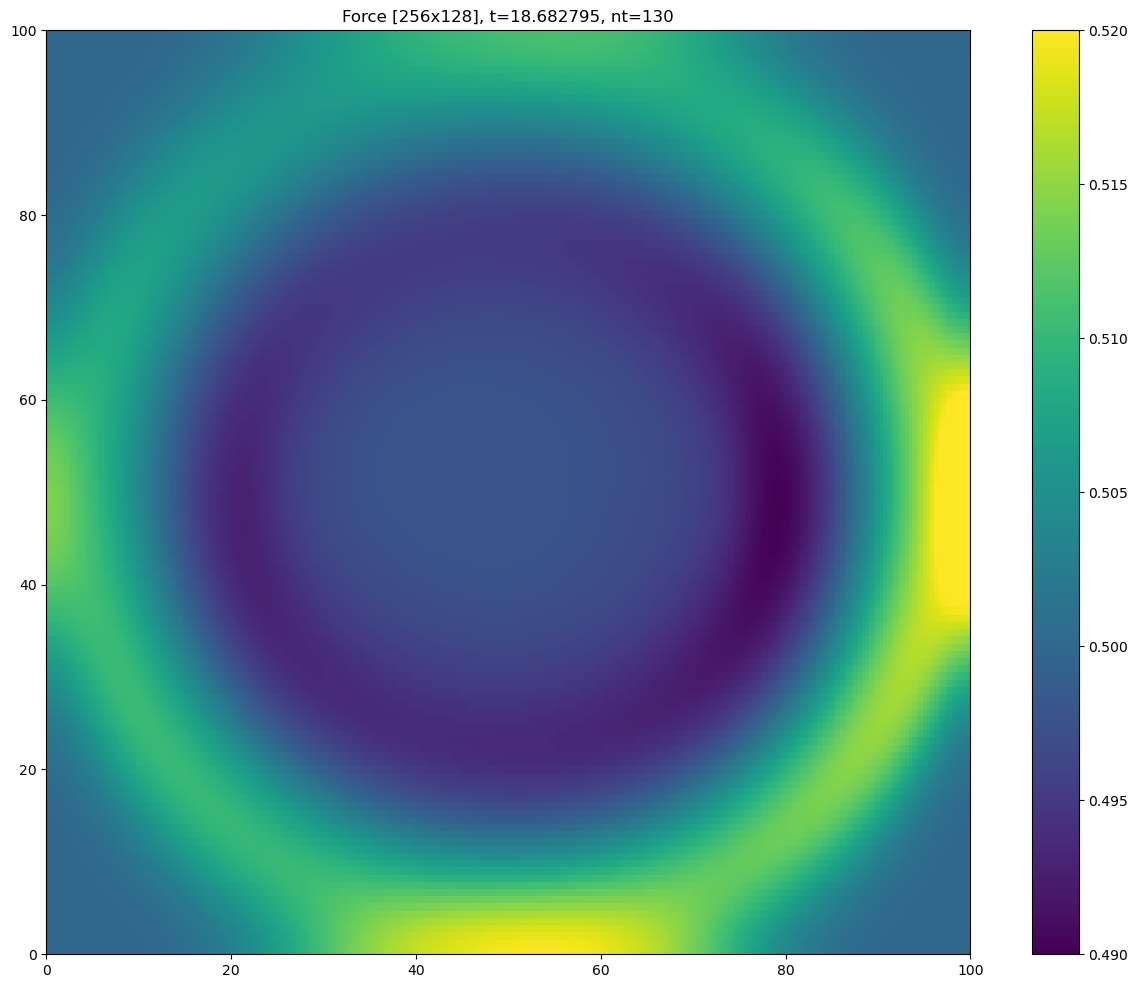

In [19]:
from GPUSimulators.model import Force

with Timer("construct") as t:
    sim = Force(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Simulation:   0%|          | 0/130 [00:00<?, ?it/s]

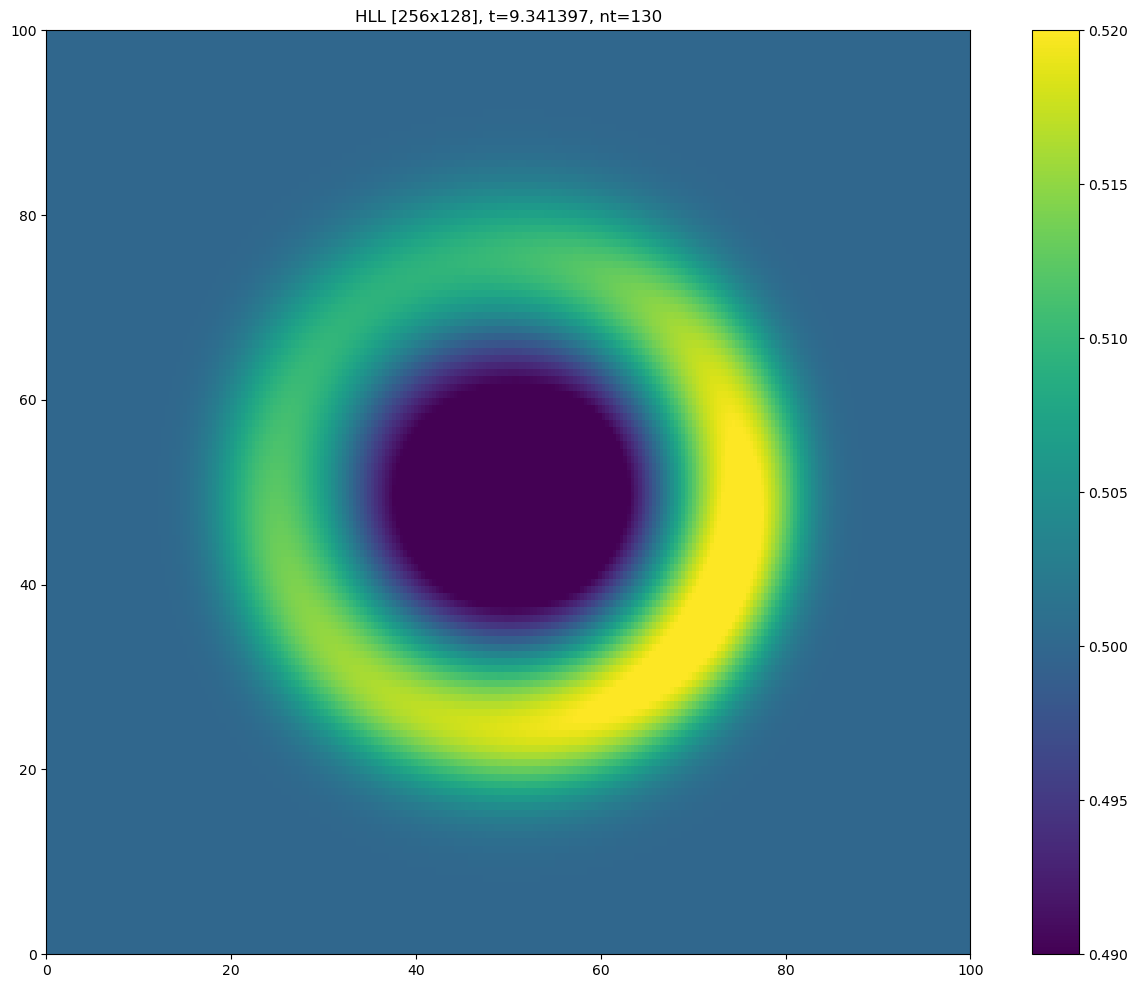

In [20]:
from GPUSimulators.model import HLL

with Timer("construct") as t:
    sim = HLL(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Simulation:   0%|          | 0/130 [00:00<?, ?it/s]

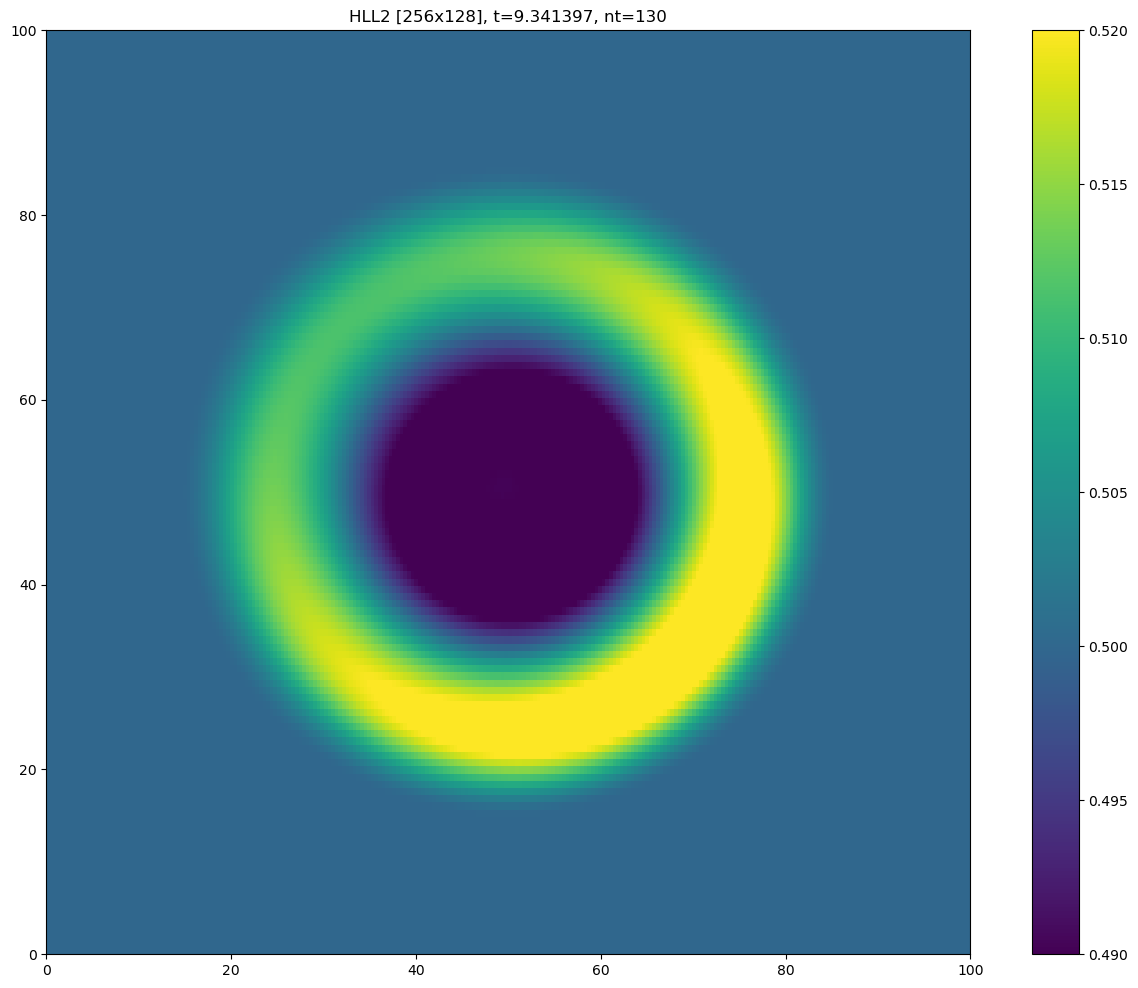

In [21]:
from GPUSimulators.model import HLL2

with Timer("construct") as t:
    sim = HLL2(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Simulation:   0%|          | 0/130 [00:00<?, ?it/s]

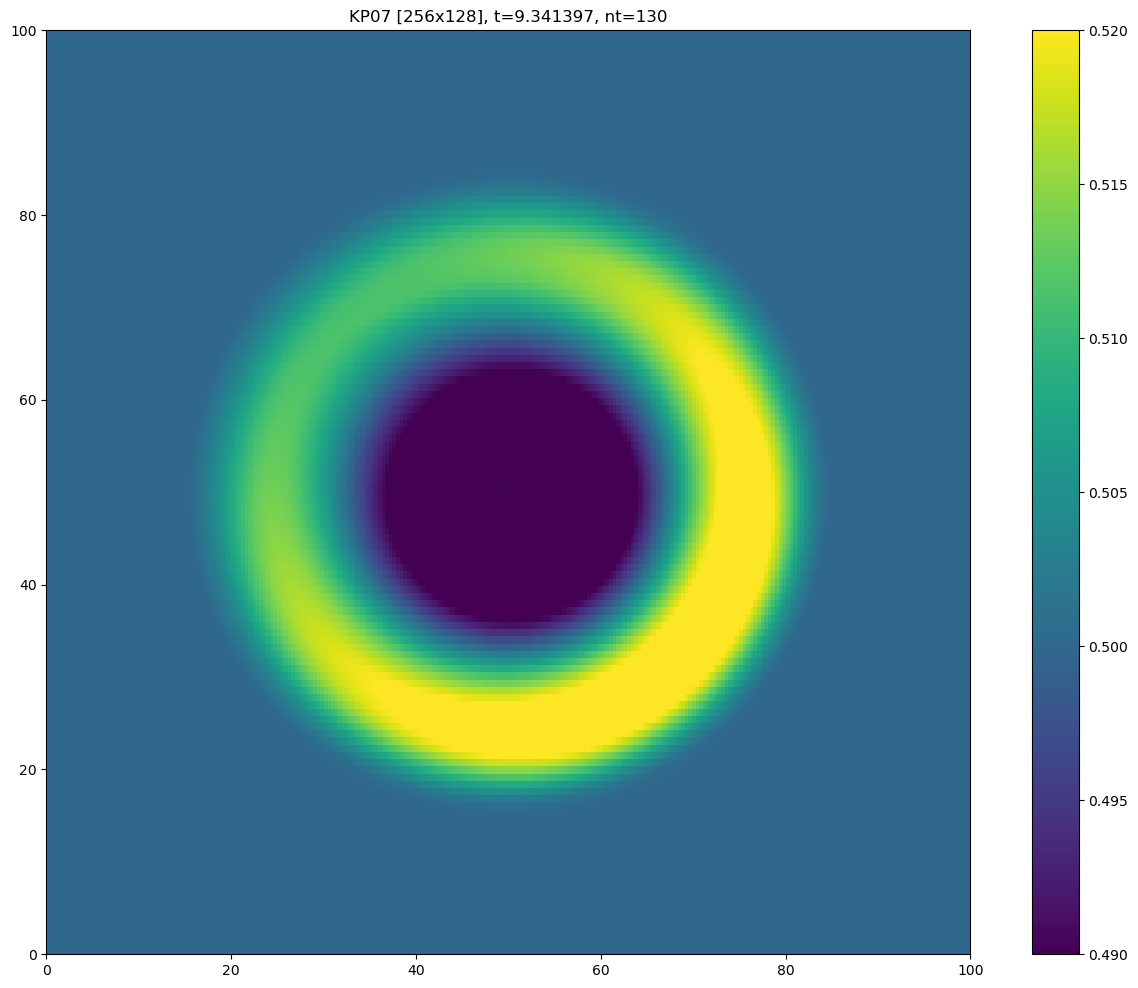

In [22]:
from GPUSimulators.model import KP07

with Timer("construct") as t:
    sim = KP07(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

Simulation:   0%|          | 0/130 [00:00<?, ?it/s]

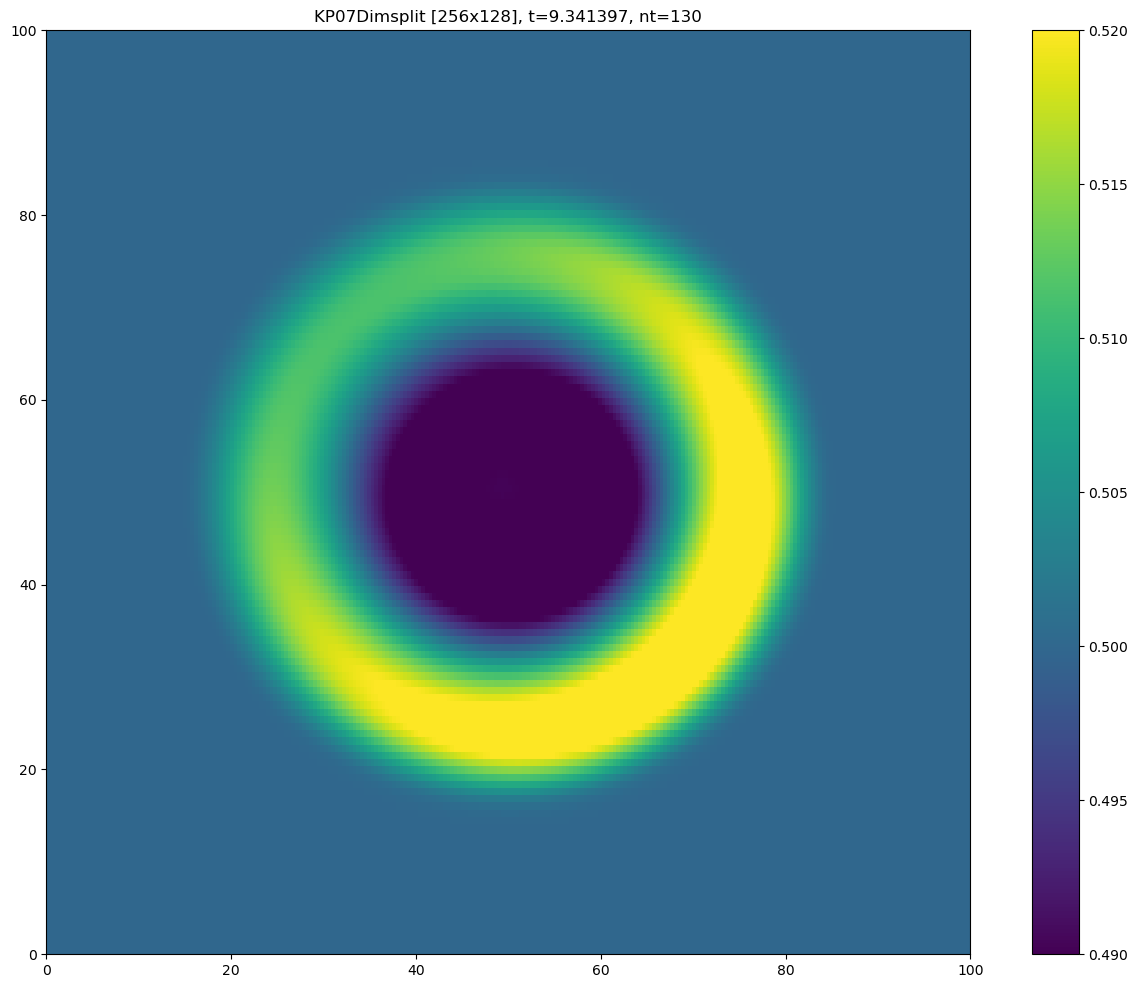

In [23]:
from GPUSimulators.model import KP07Dimsplit

with Timer("construct") as t:
    sim = KP07Dimsplit(**arguments)

with Timer("step") as t:
    t = sim.simulate(t_end)
    
with Timer("download") as t:
    h1, hu1, hv1 = sim.download()

plot(sim)

In [24]:
# from GPUSimulators.model import WAF
#
# with Timer("construct") as t:
#     sim = WAF(**arguments)
#
# with Timer("step") as t:
#     t = sim.simulate(t_end)
#
# with Timer("download") as t:
#     h1, hu1, hv1 = sim.download()
#
# plot(sim)